             NLP_Preprocessing

In [1]:
import pandas as pd
import numpy as np

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

Download NLTK Resources

In [2]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to C:\Users\LOGESH
[nltk_data]     S\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\LOGESH
[nltk_data]     S\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\LOGESH
[nltk_data]     S\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to C:\Users\LOGESH
[nltk_data]     S\AppData\Roaming\nltk_data...


True

Load Dataset

In [3]:
tasks = pd.read_csv("../data/processed/tasks_processed.csv")

Keep Required Columns

In [4]:
tasks = tasks[["Task_Description", "Category"]]
tasks.head()

,Task_Description,Category
0,House answer start behind old travel Democrat ...,Support
1,Way officer however wish another teach face ce...,Documentation
2,Recognize each off modern themselves role expl...,Enhancement
3,Of then finish receive organization oil lay st...,UI/UX
4,Can easy hospital the ball last near third sta...,Testing


In [5]:
tasks.isnull().sum()

Task_Description    0
Category            0
dtype: int64

Create a Text Cleaning Function

In [6]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    words = word_tokenize(text)

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

Apply Cleaning

In [7]:
tasks["Clean_Description"] = tasks["Task_Description"].apply(clean_text)

Compare Before & After

In [8]:
tasks[
    ["Task_Description", "Clean_Description"]
].head(10)

,Task_Description,Clean_Description
0,House answer start behind old travel Democrat ...,house answer start behind old travel democrat ...
1,Way officer however wish another teach face ce...,way officer however wish another teach face ce...
2,Recognize each off modern themselves role expl...,recognize modern role explain woman brother in...
3,Of then finish receive organization oil lay st...,finish receive organization oil lay style war ...
4,Can easy hospital the ball last near third sta...,easy hospital ball last near third standard te...
5,Activity store consumer example certainly move...,activity store consumer example certainly move...
6,Hot human billion plant artist attack decade c...,hot human billion plant artist attack decade c...
7,Lose find century see science long reality mig...,lose find century see science long reality mig...
8,Single form development specific world system ...,single form development specific world system ...
9,Like front lot world particular ability traini...,like front lot world particular ability traini...


Save the Cleaned Dataset

In [9]:
tasks.to_csv(
    "../data/processed/tasks_nlp.csv",
    index=False
)

Create a Word Cloud

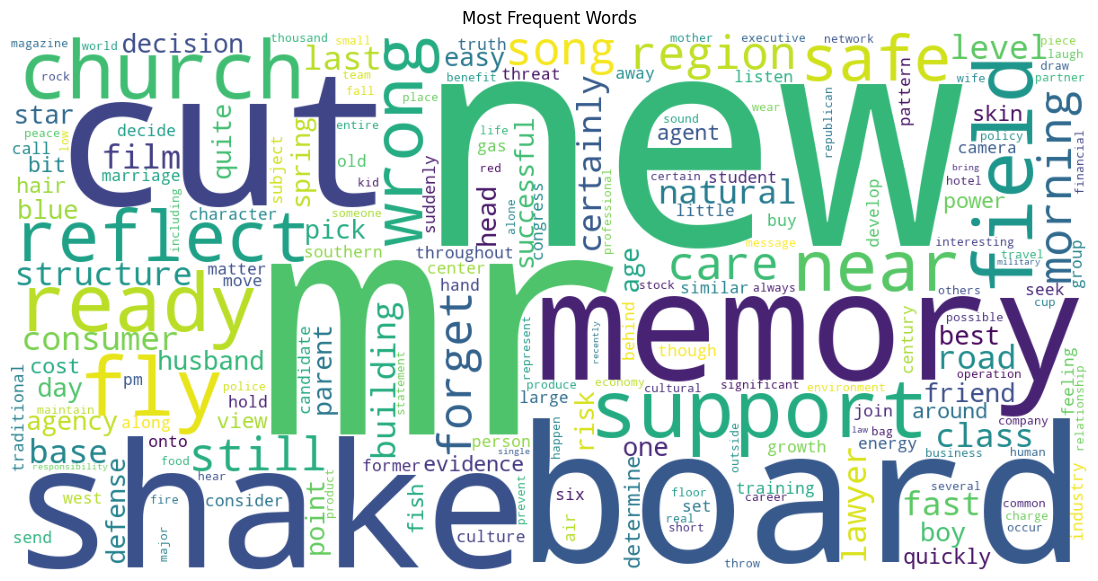

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(tasks["Clean_Description"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words")

plt.savefig(
    "../outputs/charts/wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Top 20 Most Frequent Words

In [12]:
from collections import Counter

words = " ".join(tasks["Clean_Description"]).split()

counter = Counter(words)

top20 = counter.most_common(20)

top20

[('mr', 365),
 ('board', 227),
 ('cut', 227),
 ('shake', 225),
 ('memory', 223),
 ('support', 219),
 ('field', 216),
 ('ready', 216),
 ('fly', 215),
 ('church', 214),
 ('reflect', 213),
 ('near', 212),
 ('wrong', 212),
 ('safe', 212),
 ('region', 212),
 ('care', 212),
 ('song', 211),
 ('still', 211),
 ('forget', 211),
 ('morning', 211)]

Plot Top Words

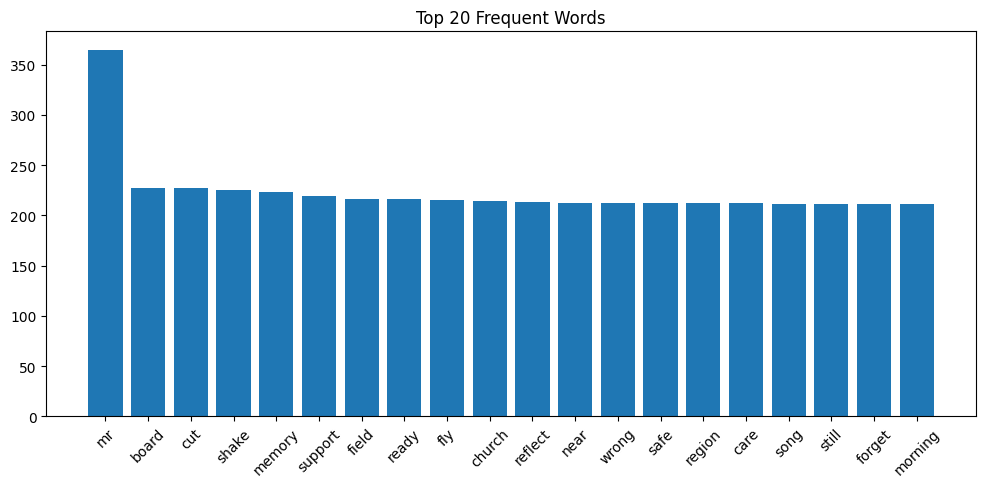

In [13]:
words = [x[0] for x in top20]
counts = [x[1] for x in top20]

plt.figure(figsize=(12,5))

plt.bar(words, counts)

plt.xticks(rotation=45)

plt.title("Top 20 Frequent Words")

plt.savefig(
    "../outputs/charts/top_words.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()